# Lecture 11: Transformer Architecture – Concepts
### NLP Course 2027

---

## Learning Outcomes
- Understand why transformers superseded RNNs
- Master the self-attention mechanism mathematically
- Understand multi-head attention and positional encoding
- Distinguish encoder-only, decoder-only, and encoder-decoder models

**Primary Reference:** *NLP with Transformers* (Tunstall et al.), Ch.3 'Transformer Anatomy'

## 1. The Problem Transformers Solve

### RNN Limitations
```
RNN processes sequentially:
  h1 → h2 → h3 → ... → hN
  (must wait for each step → slow, hard to parallelize)

Long-range dependencies:
  'The animal didn't cross the street because [it] was too tired.'
  What does 'it' refer to? Animal (12 words back)
  RNN often forgets by the time it reaches 'it'
```

### Transformer Solution
```
Transformer attends to ALL positions simultaneously:
  [The, animal, didn't, cross, ..., it, was, tired]
         ↑←←←←←←←←←←←←←←←←←←←↑
         Animal gets high attention weight from 'it'
  No sequential bottleneck → parallelizable → fast on GPUs
```

### Key paper: 'Attention Is All You Need' (Vaswani et al., 2017)
- Eliminated recurrence entirely
- Used self-attention to model global dependencies
- Enabled massive parallelism on GPUs/TPUs

## 2. Scaled Dot-Product Attention

The fundamental building block of transformers:

```
Given: Query (Q), Key (K), Value (V) matrices

Attention(Q, K, V) = softmax(QK^T / √d_k) × V
                        ↑           ↑         ↑
                   dot product    scale    weighted
                   similarity              values
```

**Intuition with a database analogy:**
- **Query** (Q): what you're searching for ('it' in the sentence)
- **Key** (K): labels in the database (every word in the sentence)
- **Value** (V): actual content at each position
- **Attention weight**: how much 'it' attends to each other word

```
      Query=it    Keys=[The, animal, ..., tired]
          ↓               ↓
     dot products: [0.1, 0.8, 0.0, 0.05, 0.0, 0.05]
          ↓
     softmax:      [0.05, 0.65, 0.01, 0.15, ...]
          ↓
     weighted sum of Values → context vector for 'it'
```

Scaling by √d_k prevents softmax from saturating with large d_k.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def scaled_dot_product_attention(Q, K, V, mask=None):
    """
    Scaled Dot-Product Attention.
    Q: (seq_q, d_k)
    K: (seq_k, d_k)
    V: (seq_k, d_v)
    """
    d_k = Q.shape[-1]
    # Compute attention scores
    scores = Q @ K.T / np.sqrt(d_k)  # (seq_q, seq_k)
    # Optional: apply mask (e.g., for causal/autoregressive models)
    if mask is not None:
        scores = np.where(mask, -1e9, scores)
    # Softmax over key dimension
    scores_exp = np.exp(scores - scores.max(axis=-1, keepdims=True))
    attention_weights = scores_exp / scores_exp.sum(axis=-1, keepdims=True)
    # Weighted sum of values
    output = attention_weights @ V
    return output, attention_weights

# Demo with random vectors
np.random.seed(42)
seq_len = 5
d_k = d_v = 4
Q = np.random.randn(seq_len, d_k)
K = np.random.randn(seq_len, d_k)
V = np.random.randn(seq_len, d_v)

output, attn_weights = scaled_dot_product_attention(Q, K, V)
print('Input shape:', Q.shape)
print('Attention weights (rows=queries, cols=keys):')
print(attn_weights.round(4))
print('Output shape:', output.shape)

Input shape: (5, 4)
Attention weights (rows=queries, cols=keys):
[[0.0881 0.1388 0.5175 0.0964 0.1591]
 [0.1244 0.1154 0.331  0.32   0.1093]
 [0.1961 0.3004 0.1703 0.1773 0.1559]
 [0.0769 0.0753 0.0452 0.0701 0.7325]
 [0.2082 0.2962 0.0786 0.2374 0.1796]]
Output shape: (5, 4)


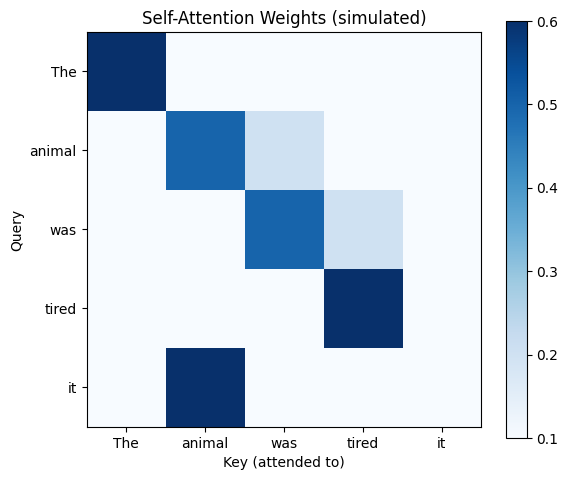

In [2]:
# Visualize attention weights
import matplotlib.pyplot as plt

tokens = ['The', 'animal', 'was', 'tired', 'it']

# Simulate attention: 'it' attends strongly to 'animal'
manual_attention = np.array([
    [0.6, 0.1, 0.1, 0.1, 0.1],  # The
    [0.1, 0.5, 0.2, 0.1, 0.1],  # animal
    [0.1, 0.1, 0.5, 0.2, 0.1],  # was
    [0.1, 0.1, 0.1, 0.6, 0.1],  # tired
    [0.1, 0.6, 0.1, 0.1, 0.1],  # it -> attends to 'animal'
])

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(manual_attention, cmap='Blues')
ax.set_xticks(range(len(tokens)))
ax.set_yticks(range(len(tokens)))
ax.set_xticklabels(tokens)
ax.set_yticklabels(tokens)
ax.set_xlabel('Key (attended to)')
ax.set_ylabel('Query')
ax.set_title('Self-Attention Weights (simulated)')
plt.colorbar(im)
plt.tight_layout()
plt.show()

## 3. Multi-Head Attention

Using a single attention function is limiting. **Multi-head attention** runs several attention operations in parallel:

```
head_1 = Attention(Q W_1^Q, K W_1^K, V W_1^V)  # syntactic relations
head_2 = Attention(Q W_2^Q, K W_2^K, V W_2^V)  # semantic relations
...
head_h = Attention(Q W_h^Q, K W_h^K, V W_h^V)  # other relations

MultiHead(Q,K,V) = Concat(head_1, ..., head_h) W^O
```

**Why multiple heads?** Each head can attend to different aspects:
- Head 1: syntactic subject-verb agreement
- Head 2: coreference resolution
- Head 3: semantic similarity

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class MultiHeadAttention(nn.Module):
    def __init__(self, embed_dim, num_heads):
        super().__init__()
        assert embed_dim % num_heads == 0
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.d_k = embed_dim // num_heads

        self.W_q = nn.Linear(embed_dim, embed_dim)
        self.W_k = nn.Linear(embed_dim, embed_dim)
        self.W_v = nn.Linear(embed_dim, embed_dim)
        self.W_o = nn.Linear(embed_dim, embed_dim)

    def split_heads(self, x):
        # x: (batch, seq, embed_dim) -> (batch, heads, seq, d_k)
        B, S, _ = x.shape
        x = x.view(B, S, self.num_heads, self.d_k)
        return x.transpose(1, 2)

    def forward(self, x, mask=None):
        B, S, _ = x.shape
        Q = self.split_heads(self.W_q(x))  # (B, heads, S, d_k)
        K = self.split_heads(self.W_k(x))
        V = self.split_heads(self.W_v(x))
        # Scaled dot-product attention
        scores = (Q @ K.transpose(-2, -1)) / (self.d_k ** 0.5)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)
        attn = F.softmax(scores, dim=-1)
        out = attn @ V  # (B, heads, S, d_k)
        # Merge heads
        out = out.transpose(1, 2).contiguous().view(B, S, self.embed_dim)
        return self.W_o(out), attn

# Test
mha = MultiHeadAttention(embed_dim=512, num_heads=8)
x = torch.randn(2, 10, 512)  # (batch=2, seq=10, dim=512)
output, attn = mha(x)
print(f'Input: {x.shape}')
print(f'Output: {output.shape}')
print(f'Attention weights: {attn.shape}  (batch, heads, seq, seq)')

Input: torch.Size([2, 10, 512])
Output: torch.Size([2, 10, 512])
Attention weights: torch.Size([2, 8, 10, 10])  (batch, heads, seq, seq)


## 4. Positional Encoding

Attention is **permutation-invariant** — it doesn't care about word order by default. Positional encodings inject order information.

### Sinusoidal Encoding (original paper)
```
PE(pos, 2i)   = sin(pos / 10000^(2i/d_model))
PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))
```

- Each position gets a unique vector
- The encoding is deterministic (no learned parameters)
- Model can interpolate to unseen sequence lengths

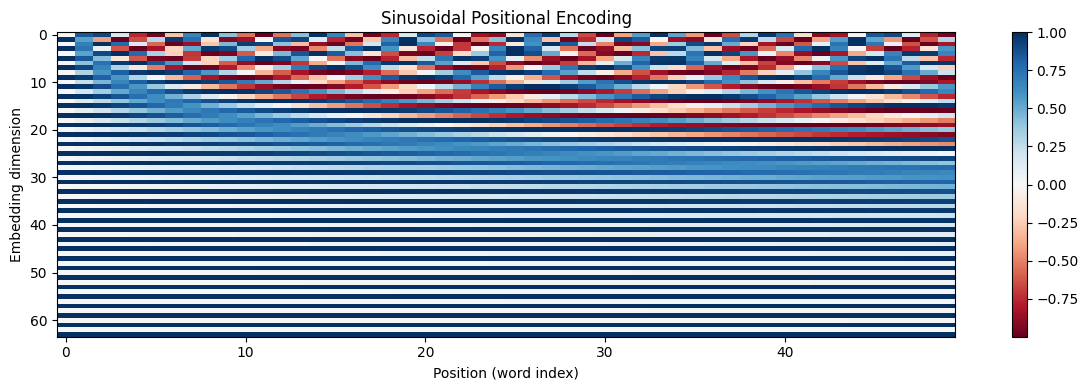

PE shape: (50, 64)  (50 positions x 64 dims)


In [4]:
def positional_encoding(max_len, d_model):
    """
    Sinusoidal positional encoding.
    Returns: (max_len, d_model) matrix
    """
    pe = np.zeros((max_len, d_model))
    positions = np.arange(max_len)[:, np.newaxis]  # (max_len, 1)
    dim_pair = np.arange(0, d_model, 2)             # even indices
    div_term = 10000 ** (dim_pair / d_model)
    pe[:, 0::2] = np.sin(positions / div_term)     # even dims
    pe[:, 1::2] = np.cos(positions / div_term)     # odd dims
    return pe

# Visualize
pe = positional_encoding(max_len=50, d_model=64)
fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(pe.T, aspect='auto', cmap='RdBu')
ax.set_xlabel('Position (word index)')
ax.set_ylabel('Embedding dimension')
ax.set_title('Sinusoidal Positional Encoding')
plt.colorbar(im)
plt.tight_layout()
plt.show()
print(f'PE shape: {pe.shape}  (50 positions x 64 dims)')

## 5. Transformer Architecture

### Encoder Block
```
 Input sequence (embedded + positional)
     ↓
 [Multi-Head Self-Attention]
     ↓ + residual connection
 [Layer Normalization]
     ↓
 [Feed-Forward Network: Linear(d_model,4*d_model) → ReLU → Linear]
     ↓ + residual connection
 [Layer Normalization]
     ↓
 Contextual representations
```

### Model Families
| Type | Architecture | Models | Use Case |
|------|-------------|--------|----------|
| Encoder-only | Self-attention, both directions | BERT, RoBERTa | Classification, NER, QA |
| Decoder-only | Masked self-attention (causal) | GPT, Llama | Text generation |
| Encoder-Decoder | Both | T5, BART, mT5 | Translation, Summarization |

In [5]:
class TransformerEncoderBlock(nn.Module):
    """Single encoder block from 'Attention Is All You Need'."""
    def __init__(self, embed_dim, num_heads, ff_dim, dropout=0.1):
        super().__init__()
        self.attention = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout,
                                               batch_first=True)
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.ff = nn.Sequential(
            nn.Linear(embed_dim, ff_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim, embed_dim),
            nn.Dropout(dropout)
        )

    def forward(self, x, key_padding_mask=None):
        # Self-attention + residual + layer norm
        attn_out, _ = self.attention(x, x, x, key_padding_mask=key_padding_mask)
        x = self.norm1(x + attn_out)
        # Feed-forward + residual + layer norm
        x = self.norm2(x + self.ff(x))
        return x

# Stack multiple encoder blocks
class TransformerEncoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_heads, ff_dim, num_layers, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.layers = nn.ModuleList([
            TransformerEncoderBlock(embed_dim, num_heads, ff_dim, dropout)
            for _ in range(num_layers)
        ])
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, x):
        out = self.embedding(x)
        for layer in self.layers:
            out = layer(out)
        return self.norm(out)

encoder = TransformerEncoder(vocab_size=10000, embed_dim=256, num_heads=8,
                              ff_dim=1024, num_layers=4)
test_input = torch.randint(0, 10000, (2, 20))  # (batch=2, seq=20)
output = encoder(test_input)
print(f'Input: {test_input.shape}')
print(f'Encoder output: {output.shape}')

Input: torch.Size([2, 20])
Encoder output: torch.Size([2, 20, 256])


## Practice Exercises

See **`Lecture-11-Homework.ipynb`** for the practice exercises accompanying this lecture.

## Summary

| Concept | Key Point |
|---------|----------|
| Self-attention | Each token attends to all others simultaneously |
| Multi-head attention | Multiple attention patterns learned in parallel |
| Positional encoding | Injects sequence order (sine waves or learned) |
| Encoder block | Attention + FFN + residuals + layer norm |
| Encoder-only | BERT: bidirectional, good for understanding |
| Decoder-only | GPT: causal, good for generation |

**Next Lecture**: Transformer Models & Libraries — Hugging Face ecosystem, tokenizers, pipelines.

---
*Book reference: NLP with Transformers Ch.3*

---
**Author: Lei Wu | © 2026 Lei Wu. All rights reserved. Unauthorized use is prohibited.**